# Brock Walking Experiments — streamlined stride/step analysis 
## Introduction: Purpose of this notebook
This notebook is meant to make IMU analysis a simple process without hours of manual scoring.  

## Quick start
### INPUTS
You'll need (as INPUTS to this function)

- the data in an H5 file (as in example data imuData_s01_s02_20260507.h5)
- a CSV file with the Trial Conditions, organized as in 'trialtable_20260507.csv': columns trial, rand3, distance, packagesize. The rest are currently ignored.
- BOUNDS: and in the future, consistent event button-presses OR a list of times at which the events occurred, approximately. Again, I prefer times.

### OUTPUTS
This analysis produces Bouts! What's a Bout About? 
A WalkingBout has:
 
- when it starts
- when it ends
  (we can then compute how long it lasted)
- quiet time before
- quiet time after
So these fields are defined within WalkingBout.

When we snip bouts, the most important thing we do is create a 'FootTrajectory' (positions and velocities through time, for example!) for the left and right feet. 

From FootTrajectory we create Strides and Steps! That's it. Our new nouns are thus
WalkingBout->FootTrajectory->Strides->Steps.

**Walking Bout Processing Pipeline**

- **A. Load** — foot IMUs (`.h5`) + trial metadata (condition `.csv` and scored
  bounds `.mat`).
- **B. Mechanize** Get both feet on the shared (synced) clock, and compute positions across time — `imu.compute_position_two_imus`.
- **C. Strides** Get Strides per foot — `imu.stride_segmentation`.
- **D. Steps** combine Strides to get Steps — `imu.steps_from_strides`: speed comes from the
  validated strides, and both feet are placed in **one frame (walking axis +Y,
  gravity Z)** so step length/width come out too.
- **E. Plot** the speed panel (raw accel / foot speed / step speed).

# Define hardcoded filenames here!

In [1]:
# --- setup ---

%matplotlib inline
import sys, os, io, contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../src'))   # stride_imu + brock_functions
import stride_imu as imu
# Agg-free data loaders from the demos; the pipeline + plotting live in the library
from brock_functions import load_feet, load_trial_bounds, walker_for, bout_sync_strides_steps

H5_FILE = os.environ.get(
    'STRIDE_DATA_FILE',
    '/Users/jeremy/Dropbox/Treadmill Brock 2025/imu data/imuData_s01_s02_20260507.h5')

CONDITION_CSV = os.environ.get(
    'STRIDE_TRIALTABLE_FILE',
    '/Users/jeremy/Dropbox/Treadmill Brock 2025/imu data/trialtable_20260507.csv')
BOUNDS_MAT = os.environ.get(
    'STRIDE_TRIALBOUNDS_FILE',
    '/Users/jeremy/Dropbox/Treadmill Brock 2025/imu data/s01_s02_ExpTrialBounds.mat')

## Configuration

These are constant configuration parameters, you should mostly not need to ever change them. They include
- Figure scales (shared across trials so they compare directly)
- spatial-frame assumptions that drive step width and the overhead's foot separation. 

In [2]:
# figure y-axis ceilings (the overhead's X axis is fixed to [-1, 1] m and Y to
# 1.10x the furthest forward point, inside plotting.draw_overhead)
ACCEL_MAX = 50.0       # m/s^2, |A|
FOOTSPEED_MAX = 3.0    # m/s, foot speed |V|
STEPSPEED_MAX = 1.6    # m/s, step speed

# spatial-frame assumptions (drive step width and the overhead foot separation)
INITIAL_SEPARATION = 0.2   # m, assumed lateral gap between the feet at the anchor
ANCHOR_MODE = 'firstonly'  # 'firstonly' puts the offset at the gait start (visible
#                            at the start); 'auto' minimizes accumulated drift

## A. Loading of Condition CSV file function
Here are functions that read the metadata from the csv files.
All metadata (condition CSV + scored bounds) loads in one function.

In [3]:
def load_metadata(condition_csv=CONDITION_CSV, bounds_mat=BOUNDS_MAT):
    """Step A metadata: the condition table (CSV: 48 rows = 16 Distance x Package
    combos x 3 reps) and the hand-scored trial bounds (.mat: 96 trials x 2 bouts,
    0-based sample indices at 100 Hz). ExpTrialBounds trial t (0-based) maps to
    condition row t % 48. Returns (conditions_df, start_idx, end_idx)."""
    conditions = pd.read_csv(condition_csv, encoding='utf-8-sig')
    start_idx, end_idx = load_trial_bounds(bounds_mat)
    return conditions, start_idx, end_idx

## Steps B–D per bout — `bout_sync_strides_steps` (from `brock_functions`)

Mechanize both feet on the shared clock, segment per-foot strides, then derive cross-foot steps (speed from strides, both feet placed in one +Y / Z frame). The scored window opens with pre-walk standing, so it snips from the detected walk onset to the scored end. Returns the speed-panel series plus the raw per-foot trajectories/strides the table needs.

## Function: per-bout table row function (and a helper to quickly produce net displacement of a bout)

Functions returning table metrics. Step length/width come from `steps_from_strides`' common frame; trust the length L/R split and mean width only when `anchor_drift_s` is below a normal stride time (~2 s).

In [4]:
def net_displacement(P):
    """Net horizontal travel of a foot trajectory (m)."""
    return float(np.linalg.norm(P[-1, :2] - P[0, :2]))


def bout_table_row(trial, bout, cond, res):
    """Key per-bout metrics (trial/bout are 1-based)."""
    steps = res['steps']
    j0, j1 = res['slice']
    walk_s = (j1 - j0) * res['period']
    spd = steps['frwd_speed']
    n_steps = len(steps['time'])
    n_strides = len(res['left_strides'].time) + len(res['right_strides'].time)
    finite = n_steps > 0
    return {
        'trial': trial, 'bout': bout, 'subject': res['subject'],
        'distance_m': cond['Distance (m)'], 'package': cond['Package size'],
        'handoff': cond['Hand-off pose'],
        'n_strides': n_strides, 'n_steps': n_steps,
        'walk_s': round(walk_s, 2),
        'cadence_spm': round(n_steps / walk_s * 60, 1) if walk_s else np.nan,
        'max_step_speed_mps': round(float(np.nanmax(spd)), 3) if finite else np.nan,
        'mean_step_speed_mps': round(float(np.mean(spd)), 3) if finite else np.nan,
        'step_speed_std': round(float(np.std(spd)), 3) if finite else np.nan,
        'step_len_m': round(float(np.mean(steps['length'])), 3) if finite else np.nan,
        'step_width_m': round(float(np.mean(steps['width'])), 3) if finite else np.nan,
        'anchor_drift_s': round(float(steps['anchor_drift_seconds']), 2),
        'net_dist_m': round(0.5 * (net_displacement(res['left_info'].P) +
                                   net_displacement(res['right_info'].P)), 2),
    }

## Run every bout → the table

In [5]:
feet = load_feet(H5_FILE)
period = feet[('s1', 'left')].period
conditions, start_idx, end_idx = load_metadata()
n_trials = start_idx.shape[0]
print(f"{n_trials} trials x 2 bouts @ {1/period:.0f} Hz")

rows = []
for trial in range(n_trials):
    cond = conditions.iloc[trial % 48]
    for bout in range(2):
        subject = walker_for(trial, bout)
        i0, i1 = int(start_idx[trial, bout]), int(end_idx[trial, bout])
        try:
            res = bout_sync_strides_steps(feet, subject, i0, i1, period, initial_separation=INITIAL_SEPARATION, anchor_mode=ANCHOR_MODE)
        except Exception as e:        # one bad bout shouldn't sink the table
            print(f"  SKIP trial {trial+1} bout {bout+1} ({subject}): {type(e).__name__}")
            continue
        rows.append(bout_table_row(trial + 1, bout + 1, cond, res))
    if (trial + 1) % 16 == 0:
        print(f"  processed {trial+1}/{n_trials}")

table = pd.DataFrame(rows)
table.to_csv(os.path.join(os.path.dirname(H5_FILE), 'cached data', 'brock_analysis_table.csv'), index=False)
print(f"\nWrote brock_analysis_table.csv  ({len(table)} bouts)")
table.head(8)

96 trials x 2 bouts @ 100 Hz


/Users/jeremy/Git/mcl/stride_estimation_imu/src/stride_imu/inertial.py:783: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(frwd_end, ltrl_end, 1)
/Users/jeremy/Git/mcl/stride_estimation_imu/src/stride_imu/inertial.py:783: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(frwd_end, ltrl_end, 1)
/Users/jeremy/Git/mcl/stride_estimation_imu/src/stride_imu/inertial.py:783: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(frwd_end, ltrl_end, 1)


  processed 16/96


/Users/jeremy/Git/mcl/stride_estimation_imu/src/stride_imu/inertial.py:783: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(frwd_end, ltrl_end, 1)
/Users/jeremy/Git/mcl/stride_estimation_imu/src/stride_imu/inertial.py:783: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(frwd_end, ltrl_end, 1)
/Users/jeremy/Git/mcl/stride_estimation_imu/src/stride_imu/inertial.py:783: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(frwd_end, ltrl_end, 1)
/Users/jeremy/Git/mcl/stride_estimation_imu/src/stride_imu/inertial.py:783: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(frwd_end, ltrl_end, 1)
/Users/jeremy/Git/mcl/stride_estimation_imu/src/stride_imu/inertial.py:783: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(frwd_end, ltrl_end, 1)
/Users/jeremy/Git/mcl/stride_estimation_imu/src/stride_imu/inertial.py:783: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(frwd_end, ltrl_

  processed 32/96


...

  processed 64/96


/Users/jeremy/Git/mcl/stride_estimation_imu/src/stride_imu/inertial.py:783: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(frwd_end, ltrl_end, 1)
/Users/jeremy/Git/mcl/stride_estimation_imu/src/stride_imu/inertial.py:783: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(frwd_end, ltrl_end, 1)
/Users/jeremy/Git/mcl/stride_estimation_imu/src/stride_imu/inertial.py:783: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(frwd_end, ltrl_end, 1)
/Users/jeremy/Git/mcl/stride_estimation_imu/src/stride_imu/inertial.py:783: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(frwd_end, ltrl_end, 1)
/Users/jeremy/Git/mcl/stride_estimation_imu/src/stride_imu/inertial.py:783: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(frwd_end, ltrl_end, 1)
/Users/jeremy/Git/mcl/stride_estimation_imu/src/stride_imu/inertial.py:783: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(frwd_end, ltrl_

  processed 80/96
  processed 96/96

Wrote brock_analysis_table.csv  (192 bouts)


/Users/jeremy/Git/mcl/stride_estimation_imu/src/stride_imu/inertial.py:783: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(frwd_end, ltrl_end, 1)
/Users/jeremy/Git/mcl/stride_estimation_imu/src/stride_imu/inertial.py:783: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(frwd_end, ltrl_end, 1)
/Users/jeremy/Git/mcl/stride_estimation_imu/src/stride_imu/inertial.py:783: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(frwd_end, ltrl_end, 1)
/Users/jeremy/Git/mcl/stride_estimation_imu/src/stride_imu/inertial.py:783: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(frwd_end, ltrl_end, 1)


,trial,bout,subject,distance_m,package,handoff,n_strides,n_steps,walk_s,cadence_spm,max_step_speed_mps,mean_step_speed_mps,step_speed_std,step_len_m,step_width_m,anchor_drift_s,net_dist_m
0,1,1,s2,8.0,5,ground,14,13,9.05,86.2,1.335,0.999,0.336,0.551,0.463,1.86,7.15
1,1,2,s1,8.0,5,ground,12,12,9.64,74.7,1.528,1.003,0.477,0.618,0.265,1.51,7.32
2,2,1,s2,12.0,5,held out,17,17,13.35,76.4,1.673,1.149,0.371,0.614,0.901,4.04,10.13
3,2,2,s1,12.0,5,held out,14,14,9.93,84.6,1.711,1.161,0.529,0.740,0.329,1.71,10.38
4,3,1,s2,5.0,10,ground,10,8,5.77,83.2,1.403,0.961,0.371,0.520,0.338,1.55,4.12
5,3,2,s1,5.0,10,ground,7,7,7.75,54.2,1.294,0.758,0.449,0.605,0.569,2.47,4.15
6,4,1,s2,2.5,5,waist,5,3,4.52,39.8,0.994,0.774,0.170,0.345,-0.086,1.61,1.69
7,4,2,s1,2.5,5,waist,5,5,6.15,48.8,0.759,0.455,0.166,0.380,0.576,3.51,1.98


### Summary by subject

In [6]:
summary = (table.groupby('subject')[['mean_step_speed_mps', 'cadence_spm', 'step_len_m',
                                     'step_width_m', 'net_dist_m']]
                .agg(['mean', 'std']).round(2))
print(summary)
summary

        mean_step_speed_mps       cadence_spm        step_len_m        \
                       mean   std        mean    std       mean   std   
subject                                                                 
s1                     0.83  0.32       65.22  20.72       0.58  0.14   
s2                     0.89  0.24       73.84  23.34       0.51  0.11   

        step_width_m       net_dist_m        
                mean   std       mean   std  
subject                                      
s1              0.35  0.32       5.61  3.49  
s2              0.28  0.52       5.53  3.48  


mean_step_speed_mps       cadence_spm        step_len_m        \
                       mean   std        mean    std       mean   std   
subject                                                                 
s1                     0.83  0.32       65.22  20.72       0.58  0.14   
s2                     0.89  0.24       73.84  23.34       0.51  0.11   

        step_width_m       net_dist_m        
                mean   std       mean   std  
subject                                      
s1              0.35  0.32       5.61  3.49  
s2              0.28  0.52       5.53  3.48

## E. Per-bout speed panel for one trial

The two bouts stacked; each = a top-down foot-position map on the left in real metres (walk climbs +Y with Y=0 at the gait start, walker's left on the left, feet ~`INITIAL_SEPARATION` apart at the start) and accel / foot speed / step speed on the right half (time = 0 at the snug gait start). Scales come from the Configuration cell; the overhead's X axis is fixed to [-1, 1] m and Y to 1.10x the furthest forward point. Change `TRIAL` to inspect any trial — the same figure the batch writes as `brock_trial<N>_velocity.svg`.

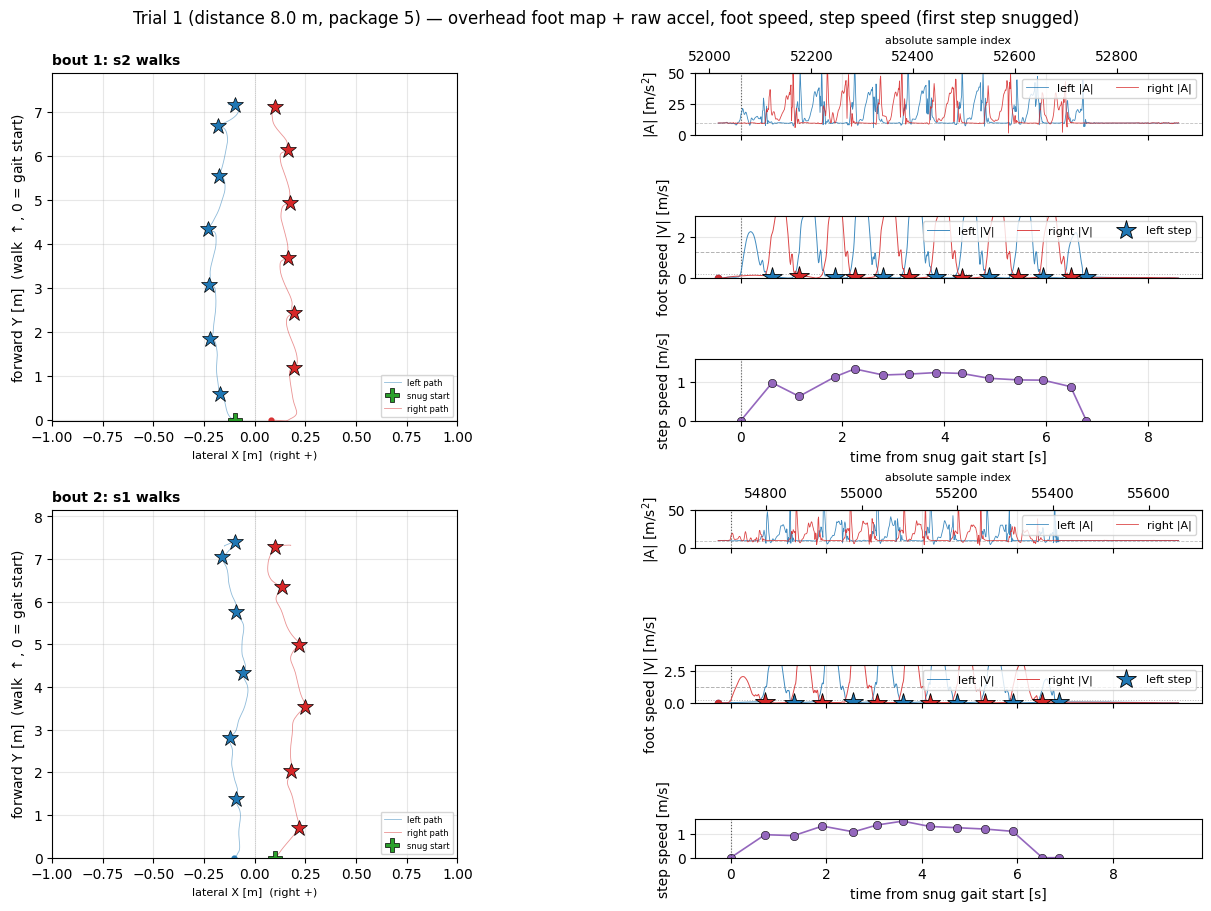

In [7]:
TRIAL = 1            # 1-based; change to inspect any trial

fig = plt.figure(figsize=(12, 9), constrained_layout=True)
outer = fig.add_gridspec(2, 1)
for b, bout in enumerate(range(2)):
    subject = walker_for(TRIAL - 1, bout)
    i0, i1 = int(start_idx[TRIAL - 1, bout]), int(end_idx[TRIAL - 1, bout])
    res = bout_sync_strides_steps(feet, subject, i0, i1, period, initial_separation=INITIAL_SEPARATION, anchor_mode=ANCHOR_MODE)
    axes4 = imu.make_bout_axes(fig, outer[b])    # overhead + accel/|V|/step
    axes4[0].set_title(f'bout {bout+1}: {subject} walks', loc='left',
                       fontsize=10, fontweight='bold')
    imu.draw_bout_block(axes4, res,
                        ymax=(ACCEL_MAX, FOOTSPEED_MAX, STEPSPEED_MAX))

cond = conditions.iloc[(TRIAL - 1) % 48]
fig.suptitle(f"Trial {TRIAL} (distance {cond['Distance (m)']} m, package "
             f"{cond['Package size']}) — overhead foot map + raw accel, foot "
             f"speed, step speed (first step snugged)")
plt.show()

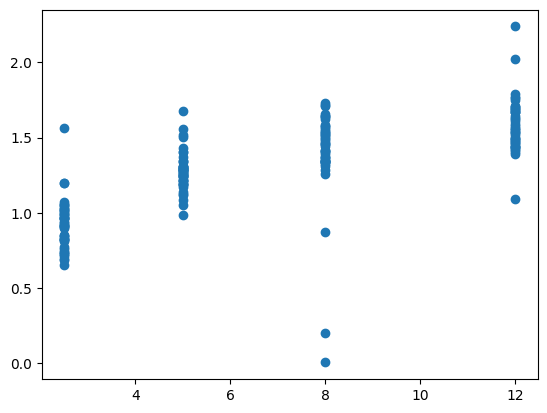

In [8]:
# and now maximum from the same column 
plt.scatter(table['distance_m'],table['max_step_speed_mps'])


